# From College to Career: A Statistical Analysis of Student Employability Factors

### Name: Jiyeon Chun
---

## Introduction

Career advisors frequently rely on intuition when guiding students, encouraging internships, recommending GPA improvements, or suggesting extracurricular involvement, without always having quantitative evidence to support which actions most effectively enhance employability. This study aims to bridge that gap by leveraging the Education and Career Success dataset to systematically analyze which factors are most strongly associated with early career outcomes. Specifically, it examines the influence of academic performance, experiential learning, and soft skills on metrics such as starting salary, number of job offers, and time to promotion.

A key hypothesis underlying this analysis is that experiential learning opportunities, including internships and hands on projects, may be as influential as, and in some cases more influential than, GPA alone. In addition, the project investigates the role of soft skills, particularly networking, which are often undervalued by students despite their potential importance in career advancement. By quantifying these relationships, the findings aim to provide evidence based insights that can help career advisors prioritize their recommendations and better support student development strategies.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Load the Dataset
- Download the dataset from Kaggle: https://www.kaggle.com/datasets/adilshamim8/education-and-career-success

In [3]:
df = pd.read_csv('education_career_success.csv')

print(f"Shape: {df.shape}")
print(df.head(3))

Shape: (400, 19)
  Student_ID  Age  Gender  High_School_GPA  SAT_Score  University_GPA  \
0       S001   22    Male              3.8       1450             3.6   
1       S002   24  Female              3.6       1380             3.4   
2       S003   21    Male              3.9       1520             3.8   

     Field_of_Study  Internships_Completed  Projects_Completed  \
0  Computer Science                      3                   7   
1          Business                      2                   5   
2       Engineering                      4                   9   

   Certifications  Soft_Skills_Score  Networking_Score  Job_Offers  \
0               2                  8                 7           3   
1               3                  7                 6           2   
2               4                  9                 8           4   

   Starting_Salary  Career_Satisfaction  Years_to_Promotion Current_Job_Level  \
0            85000                    8                   2    

### Explore the Data

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             400 non-null    str    
 1   Age                    400 non-null    int64  
 2   Gender                 400 non-null    str    
 3   High_School_GPA        400 non-null    float64
 4   SAT_Score              400 non-null    int64  
 5   University_GPA         400 non-null    float64
 6   Field_of_Study         400 non-null    str    
 7   Internships_Completed  400 non-null    int64  
 8   Projects_Completed     400 non-null    int64  
 9   Certifications         400 non-null    int64  
 10  Soft_Skills_Score      400 non-null    int64  
 11  Networking_Score       400 non-null    int64  
 12  Job_Offers             400 non-null    int64  
 13  Starting_Salary        400 non-null    int64  
 14  Career_Satisfaction    400 non-null    int64  
 15  Years_to_Promotio

In [5]:
df.describe()

,Age,High_School_GPA,SAT_Score,University_GPA,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Work_Life_Balance
count,400.000000,400.00000,400.000000,400.000000,400.000000,400.00000,400.0000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,23.000000,3.62425,1388.600000,3.441000,2.500000,6.23500,2.6250,7.932500,6.932500,2.740000,87562.500000,7.792500,2.915000,6.412500
std,1.415985,0.18795,114.311889,0.285522,1.061988,1.90232,1.2702,1.314253,1.318062,1.355357,29685.419892,1.372645,1.340622,0.929788
min,21.000000,3.20000,1160.000000,2.800000,0.000000,2.00000,0.0000,5.000000,4.000000,0.000000,31000.000000,5.000000,1.000000,5.000000
25%,22.000000,3.50000,1300.000000,3.200000,2.000000,5.00000,2.0000,7.000000,6.000000,2.000000,68000.000000,7.000000,2.000000,6.000000
50%,23.000000,3.60000,1380.000000,3.450000,3.000000,6.00000,3.0000,8.000000,7.000000,3.000000,84000.000000,8.000000,3.000000,6.000000
75%,24.000000,3.80000,1480.000000,3.700000,3.000000,8.00000,3.0000,9.000000,8.000000,4.000000,105250.000000,9.000000,4.000000,7.000000
max,25.000000,3.90000,1580.000000,4.000000,4.000000,9.00000,5.0000,10.000000,9.000000,5.000000,152000.000000,10.000000,5.000000,9.000000


### Check for Missing Values & Duplicates

In [6]:
missing = df.isnull().sum()
print("Missing values:\n", missing)

duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

Missing values:
 Student_ID               0
Age                      0
Gender                   0
High_School_GPA          0
SAT_Score                0
University_GPA           0
Field_of_Study           0
Internships_Completed    0
Projects_Completed       0
Certifications           0
Soft_Skills_Score        0
Networking_Score         0
Job_Offers               0
Starting_Salary          0
Career_Satisfaction      0
Years_to_Promotion       0
Current_Job_Level        0
Work_Life_Balance        0
Entrepreneurship         0
dtype: int64

Duplicate rows: 0


### Validate Value Ranges

In [7]:
print("High School GPA range:", df['High_School_GPA'].min(), "–", df['High_School_GPA'].max())
print("University GPA range:  ", df['University_GPA'].min(), "–", df['University_GPA'].max())

High School GPA range: 3.2 – 3.9
University GPA range:   2.8 – 4.0


---

# Comparative Analysis of Starting Salary Distributions by Field of Study
## RQ1: Do starting salary distributions differ across fields of study?

  * **Null Hypothesis ($H_0$):** The distribution of starting salaries is the same across all fields of study.

  * **Alternative Hypothesis ($H_A$):** At least one field of study has a different starting salary distribution.

To explore this, **Kernel Density Estimation (KDE)** will be used as a visualization tool to compare distribution shapes. A **Kolmogorov–Smirnov (KS) test** will be conducted to formally assess whether differences between distributions are statistically significant.

### KDE Plot by Field of Study

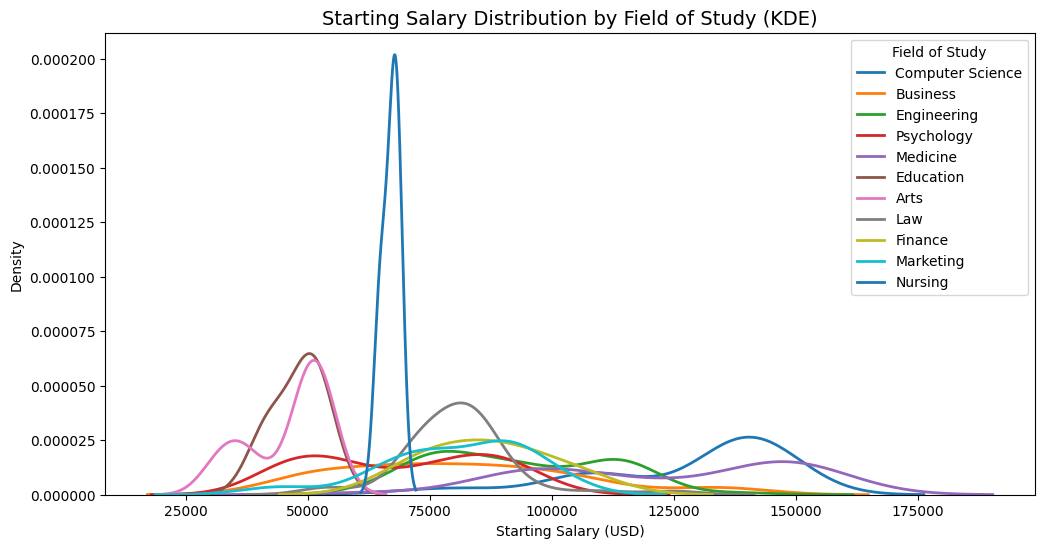

In [8]:
fields = df['Field_of_Study'].unique()

plt.figure(figsize=(12, 6))

for field in fields:
    subset = df[df['Field_of_Study'] == field]['Starting_Salary']
    sns.kdeplot(subset, label=field, fill=False, linewidth=2)

plt.title('Starting Salary Distribution by Field of Study (KDE)', fontsize=14)
plt.xlabel('Starting Salary (USD)')
plt.ylabel('Density')
plt.legend(title='Field of Study')
plt.show()

### Summary Statistics per Field

In [9]:
salary_summary = df.groupby('Field_of_Study')['Starting_Salary'].agg(
    Count='count',
    Median='median',
    Mean='mean',
    Std='std',
    Min='min',
    Max='max'
).sort_values('Median', ascending=False).round(0)

print(salary_summary)

                  Count    Median      Mean      Std    Min     Max
Field_of_Study                                                     
Computer Science     49  138000.0  127857.0  20513.0  70000  148000
Medicine             35  118000.0  123343.0  26054.0  62000  152000
Engineering          58   92000.0   93483.0  17815.0  60000  138000
Finance               5   88000.0   87000.0  12806.0  72000  105000
Law                  44   82000.0   80932.0  11697.0  54000  125000
Business             72   81000.0   81486.0  24214.0  48000  134000
Marketing            44   81000.0   80318.0  15109.0  40000  102000
Psychology           55   72000.0   69164.0  17895.0  42000  100000
Nursing               3   68000.0   67000.0   1732.0  65000   68000
Arts                 32   50000.0   46094.0   8005.0  31000   54000
Education             3   50000.0   48000.0   5292.0  42000   52000


### Kolmogorov-Smirnov (KS) Test

In [10]:
from itertools import combinations

field_groups = {field: df[df['Field_of_Study'] == field]['Starting_Salary'].values
                for field in df['Field_of_Study'].unique()}

results = []

for f1, f2 in combinations(field_groups.keys(), 2):
    stat, p_value = stats.ks_2samp(field_groups[f1], field_groups[f2])
    results.append({
        'Field 1': f1,
        'Field 2': f2,
        'KS Statistic': round(stat, 4),
        'p-value': round(p_value, 4),
        'Significant (p<0.05)': 'Yes' if p_value < 0.05 else 'No'
    })

ks_results = pd.DataFrame(results).sort_values('p-value')
print(ks_results.to_string(index=False))

         Field 1     Field 2  KS Statistic  p-value Significant (p<0.05)
Computer Science    Business        0.7656   0.0000                  Yes
            Arts   Marketing        0.9318   0.0000                  Yes
            Arts     Finance        1.0000   0.0000                  Yes
            Arts         Law        0.9545   0.0000                  Yes
        Medicine   Marketing        0.8234   0.0000                  Yes
        Medicine         Law        0.8805   0.0000                  Yes
        Medicine        Arts        1.0000   0.0000                  Yes
      Psychology        Arts        0.7636   0.0000                  Yes
     Engineering        Arts        1.0000   0.0000                  Yes
     Engineering    Medicine        0.5655   0.0000                  Yes
     Engineering  Psychology        0.4564   0.0000                  Yes
        Business        Arts        0.7917   0.0000                  Yes
      Psychology    Medicine        0.8961   0.0000

### Interpret the Results

- The KS statistic tells you how far apart two distributions are (0 = identical, 1 = completely separate), while the p-value tells you whether that gap is statistically significant.

In [11]:
sig_pairs = ks_results[ks_results['Significant (p<0.05)'] == 'Yes']
non_sig_pairs = ks_results[ks_results['Significant (p<0.05)'] == 'No']

print(f"Total field pairs tested: {len(ks_results)}")
print(f"Significantly different pairs: {len(sig_pairs)}")
print(f"Not significantly different:   {len(non_sig_pairs)}")
print()
print("Pairs with significant differences:")
print(sig_pairs[['Field 1', 'Field 2', 'KS Statistic', 'p-value']].to_string(index=False))

Total field pairs tested: 55
Significantly different pairs: 45
Not significantly different:   10

Pairs with significant differences:
         Field 1     Field 2  KS Statistic  p-value
Computer Science    Business        0.7656   0.0000
            Arts   Marketing        0.9318   0.0000
            Arts     Finance        1.0000   0.0000
            Arts         Law        0.9545   0.0000
        Medicine   Marketing        0.8234   0.0000
        Medicine         Law        0.8805   0.0000
        Medicine        Arts        1.0000   0.0000
      Psychology        Arts        0.7636   0.0000
     Engineering        Arts        1.0000   0.0000
     Engineering    Medicine        0.5655   0.0000
     Engineering  Psychology        0.4564   0.0000
        Business        Arts        0.7917   0.0000
      Psychology    Medicine        0.8961   0.0000
Computer Science   Marketing        0.9184   0.0000
Computer Science        Arts        1.0000   0.0000
Computer Science Engineering      

### Perfect Separation Pairs (KS = 1.0)

- Because the dataset is synthetic, the very clean separations (KS = 1.0, p = 0.0000) and the high proportion of significant pairs should be interpreted cautiously. Real-world salary data would have far more overlap due to individual variation, location, company size, and so on. So the direction of the findings is meaningful, but the magnitude of separation is likely inflated.

In [12]:
perfect_sep = ks_results[ks_results['KS Statistic'] == 1.0]

print(f"Pairs with perfect separation: {len(perfect_sep)}\n")
print(perfect_sep[['Field 1', 'Field 2', 'KS Statistic', 'p-value']].to_string(index=False))

Pairs with perfect separation: 13

         Field 1   Field 2  KS Statistic  p-value
            Arts   Finance           1.0   0.0000
        Medicine      Arts           1.0   0.0000
     Engineering      Arts           1.0   0.0000
Computer Science      Arts           1.0   0.0000
       Education       Law           1.0   0.0001
Computer Science Education           1.0   0.0001
     Engineering Education           1.0   0.0001
Computer Science   Nursing           1.0   0.0001
        Medicine Education           1.0   0.0002
            Arts   Nursing           1.0   0.0003
       Education   Finance           1.0   0.0357
         Finance   Nursing           1.0   0.0357
       Education   Nursing           1.0   0.1000


### High-Earning Cluster

In [13]:
high_earning = ['Computer Science', 'Engineering', 'Medicine']

salary_stats = df[df['Field_of_Study'].isin(high_earning)] \
    .groupby('Field_of_Study')['Starting_Salary'] \
    .agg(Median='median', Mean='mean', Std='std') \
    .round(0) \
    .sort_values('Median', ascending=False)

print("High-Earning Cluster Summary:\n")
print(salary_stats)

High-Earning Cluster Summary:

                    Median      Mean      Std
Field_of_Study                               
Computer Science  138000.0  127857.0  20513.0
Medicine          118000.0  123343.0  26054.0
Engineering        92000.0   93483.0  17815.0


### The 10 Non-Significant Pairs

In [14]:
print(non_sig_pairs[['Field 1', 'Field 2', 'KS Statistic', 'p-value']].to_string(index=False))

    Field 1   Field 2  KS Statistic  p-value
   Business   Nursing        0.6944   0.0681
  Education   Nursing        1.0000   0.1000
   Business Marketing        0.2222   0.1130
 Psychology   Finance        0.4909   0.1669
   Business   Finance        0.4167   0.3024
 Psychology   Nursing        0.5273   0.3045
        Law   Finance        0.4182   0.3082
Engineering   Finance        0.3448   0.5400
  Education      Arts        0.3125   0.8886
    Finance Marketing        0.2091   0.9618


---
# Effect of Multiple Internships on Starting Salary
## RQ2: Is there a statistically significant difference in median starting salary between students with no internships and those with two or more internships?

  * **Null Hypothesis ($H_0$):** The median starting salary is the same for students with 0 internships and those with ≥2 internships.

  * **Alternative Hypothesis ($H_A$):** The median starting salary differs between these two groups.

This will be evaluated using **bootstrap resampling** to estimate confidence intervals for the median difference.

### Engineer the Internship Groups

In [15]:
df['Internship_Group'] = df['Internships_Completed'].apply(
    lambda x: 'No Internship' if x == 0 else ('2+ Internships' if x >= 2 else '1 Internship')
)

# Filter to just the two groups being compared
group_0 = df[df['Internship_Group'] == 'No Internship']['Starting_Salary'].values
group_2plus = df[df['Internship_Group'] == '2+ Internships']['Starting_Salary'].values

print(f"Group 0 internship:  n={len(group_0)},  median=${np.median(group_0):,.0f}")
print(f"Group 2+ internships: n={len(group_2plus)}, median=${np.median(group_2plus):,.0f}")
print(f"\nObserved median difference: ${np.median(group_2plus) - np.median(group_0):,.0f}")

Group 0 internship:  n=10,  median=$34,500
Group 2+ internships: n=321, median=$90,000

Observed median difference: $55,500


### Bootstrap Resampling

In [16]:
np.random.seed(42)
n_iterations = 10000
bootstrap_diffs = []

for _ in range(n_iterations):
    sample_0 = np.random.choice(group_0, size=len(group_0), replace=True)
    sample_2plus = np.random.choice(group_2plus, size=len(group_2plus), replace=True)
    diff = np.median(sample_2plus) - np.median(sample_0)
    bootstrap_diffs.append(diff)

bootstrap_diffs = np.array(bootstrap_diffs)

# 95% confidence interval
ci_lower, ci_upper = np.percentile(bootstrap_diffs, [2.5, 97.5])
observed_diff = np.median(group_2plus) - np.median(group_0)

print(f"Observed median difference: ${observed_diff:,.0f}")
print(f"95% Confidence Interval: [${ci_lower:,.0f}, ${ci_upper:,.0f}]")

Observed median difference: $55,500
95% Confidence Interval: [$50,000, $59,000]


### Visualize the Bootstrap Distribution

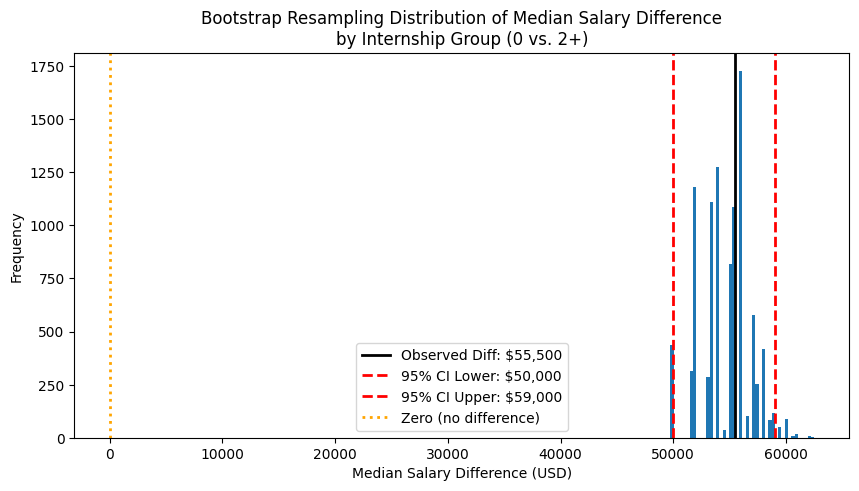

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(bootstrap_diffs, bins=50,)
plt.axvline(observed_diff, color='black',  linewidth=2, linestyle='-', label=f'Observed Diff: ${observed_diff:,.0f}')
plt.axvline(ci_lower, color='red', linewidth=2, linestyle='--', label=f'95% CI Lower: ${ci_lower:,.0f}')
plt.axvline(ci_upper, color='red', linewidth=2, linestyle='--', label=f'95% CI Upper: ${ci_upper:,.0f}')
plt.axvline(0, color='orange', linewidth=2, linestyle=':', label='Zero (no difference)')

plt.title('Bootstrap Resampling Distribution of Median Salary Difference\nby Internship Group (0 vs. 2+)')
plt.xlabel('Median Salary Difference (USD)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

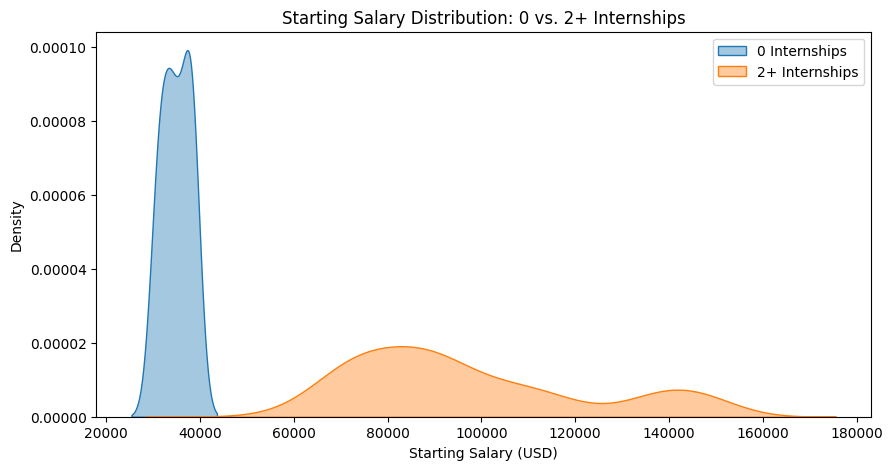

In [18]:
plt.figure(figsize=(10, 5))
sns.kdeplot(group_0, fill=True, alpha=0.4, label='0 Internships')
sns.kdeplot(group_2plus, fill=True, alpha=0.4, label='2+ Internships')

plt.title('Starting Salary Distribution: 0 vs. 2+ Internships')
plt.xlabel('Starting Salary (USD)')
plt.ylabel('Density')
plt.legend()
plt.show()

---
# Identifying Key Drivers of Early Career Success
## RQ3: Identifying the Strongest Predictors of Early Career Outcomes Across Academic, Experiential, and Soft Skill Domains

Using both Pearson correlation and Random Forest feature importance, this analysis provides a ranked, evidence-based picture of what drives early career outcomes, with particular attention to whether internships and networking outperform GPA as predictors of success.

### Define Candidate Factors

In [19]:
features = [
    'High_School_GPA',
    'SAT_Score',
    'University_GPA',
    'Internships_Completed',
    'Projects_Completed',
    'Certifications',
    'Soft_Skills_Score',
    'Networking_Score'
]

outcomes = ['Starting_Salary', 'Job_Offers', 'Years_to_Promotion']

### Correlation Matrix (Features vs. Outcomes)

In [20]:
corr_data = df[features + outcomes].corr()

# Extract only feature → outcome correlations
corr_subset = corr_data.loc[features, outcomes]

print(corr_subset.round(3))

                       Starting_Salary  Job_Offers  Years_to_Promotion
High_School_GPA                  0.951       0.966              -0.961
SAT_Score                        0.952       0.966              -0.956
University_GPA                   0.956       0.965              -0.963
Internships_Completed            0.938       0.966              -0.940
Projects_Completed               0.943       0.967              -0.935
Certifications                   0.968       0.971              -0.925
Soft_Skills_Score                0.953       0.957              -0.944
Networking_Score                 0.953       0.957              -0.944


### Heatmap: Feature vs. Outcome Coorelations

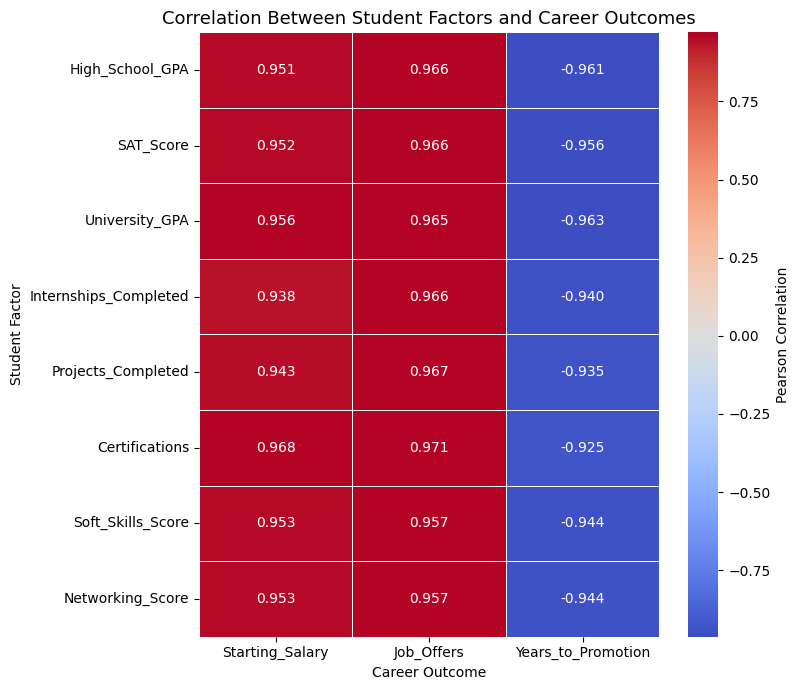

In [21]:
plt.figure(figsize=(8, 7))
sns.heatmap(
    corr_subset,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation'}
)

plt.title('Correlation Between Student Factors and Career Outcomes', fontsize=13)
plt.xlabel('Career Outcome')
plt.ylabel('Student Factor')
plt.tight_layout()
plt.show()

### Ranked Bar Chart: What Predicts Starting Salary Most?

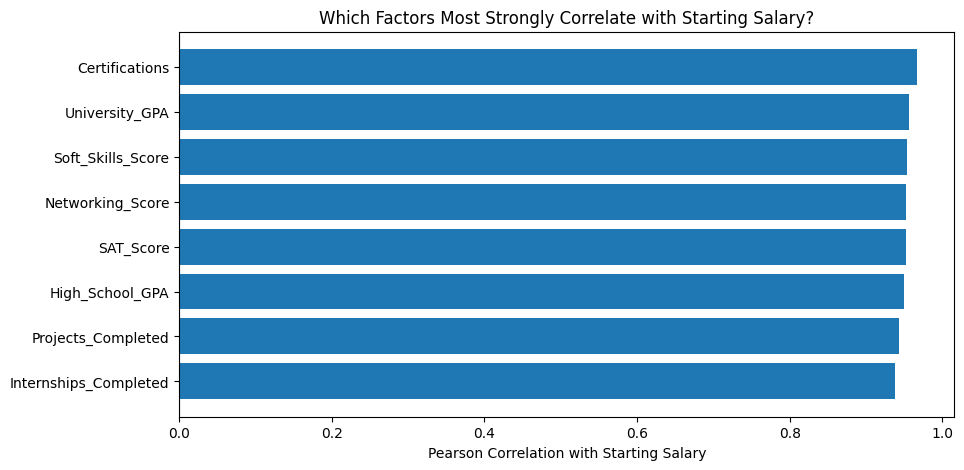

In [22]:
salary_corr = corr_subset['Starting_Salary'].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.barh(salary_corr.index, salary_corr.values)
plt.axvline(0)
plt.xlabel('Pearson Correlation with Starting Salary')
plt.title('Which Factors Most Strongly Correlate with Starting Salary?')
plt.gca().invert_yaxis()
plt.show()

### Random Forest Feature Importance

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

df_model = df[features + ['Starting_Salary']].copy()

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(df_model[features], df_model['Starting_Salary'])

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df.round(4))

                 Feature  Importance
2         University_GPA      0.6111
3  Internships_Completed      0.0982
1              SAT_Score      0.0935
5         Certifications      0.0834
0        High_School_GPA      0.0602
4     Projects_Completed      0.0244
6      Soft_Skills_Score      0.0194
7       Networking_Score      0.0097


### Plot Feature Importance

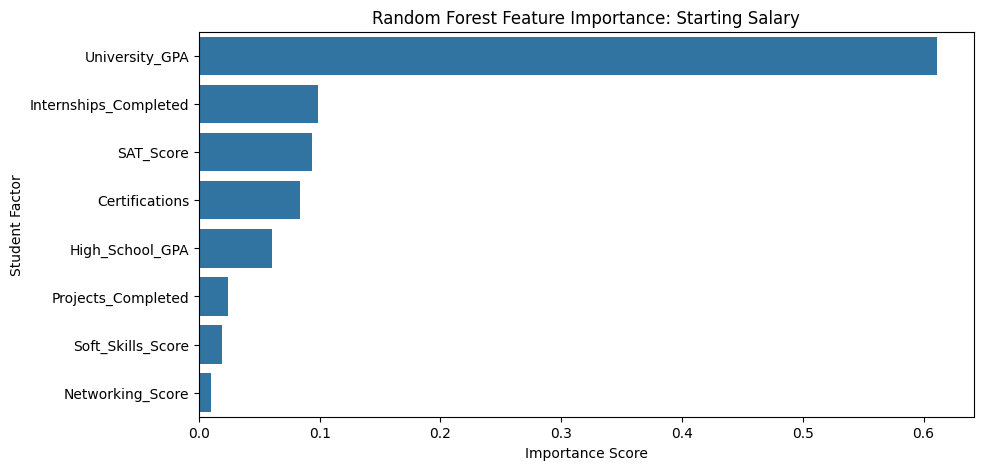

In [24]:
plt.figure(figsize=(10, 5))

sns.barplot(data=importance_df, x='Importance', y='Feature')

plt.title('Random Forest Feature Importance: Starting Salary')
plt.xlabel('Importance Score')
plt.ylabel('Student Factor')
plt.show()

### Job Offers and Years to Promotion

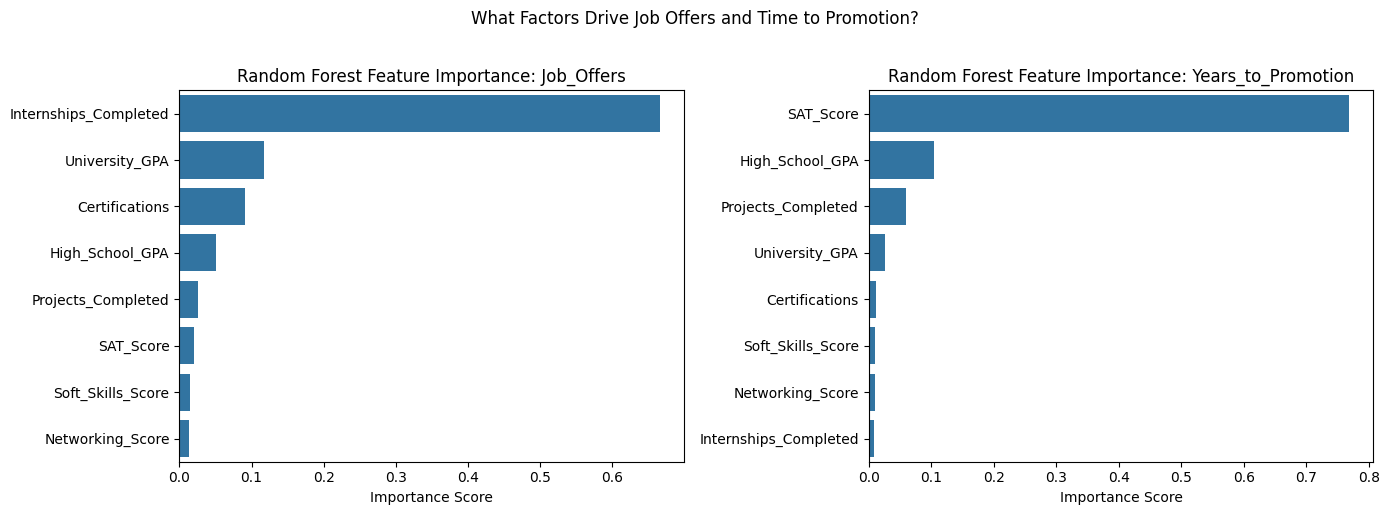

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, outcome in zip(axes, ['Job_Offers', 'Years_to_Promotion']):
    rf_temp = RandomForestRegressor(n_estimators=200, random_state=42)
    rf_temp.fit(df_model[features], df[outcome])
    
    imp = pd.DataFrame({
        'Feature': features,
        'Importance': rf_temp.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    sns.barplot(data=imp, x='Importance', y='Feature', ax=ax)
    ax.set_title(f'Random Forest Feature Importance: {outcome}')
    ax.set_xlabel('Importance Score')
    ax.set_ylabel('')

plt.suptitle('What Factors Drive Job Offers and Time to Promotion?', y=1.02)
plt.tight_layout()
plt.show()